<a href="https://colab.research.google.com/github/ayang470/CXR-Triage/blob/main/GradCam_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: GradCam Project for medical Chest X-ray images

# Install Necessary Packages and Libraries
First, we install torchxrayvision, which downloaded necessary packages for analysis.


In [ ]:
!pip install torchxrayvision

# Load Pre-trained Model
We use a Densenet-121 using Residual 224x1 layer to analyze an NIH CXR-14 image. From output, numpy will identify the disease modality with the probability that the disease is acccustomed to the label.

In [ ]:
import torchxrayvision as xrv
import skimage, torch, torchvision

img = skimage.io.imread("/content/00000013_005.png")
img = xrv.datasets.normalize(img, 255)
img = img.mean(2)[None, ...] if img.ndim == 3 else img[None, ...]

transform = torchvision.transforms.Compose([
    xrv.datasets.XRayCenterCrop(),
    xrv.datasets.XRayResizer(224)
])
img = transform(img)

model = xrv.models.DenseNet(weights="densenet121-res224-all")
outputs = model(torch.from_numpy(img)[None, ...])
print(dict(zip(model.pathologies, outputs[0].detach().numpy())))


{'Atelectasis': np.float32(0.51668787), 'Consolidation': np.float32(0.5407269), 'Infiltration': np.float32(0.5688069), 'Pneumothorax': np.float32(0.53866804), 'Edema': np.float32(0.50316155), 'Emphysema': np.float32(0.50910497), 'Fibrosis': np.float32(0.5140977), 'Effusion': np.float32(0.5209452), 'Pneumonia': np.float32(0.73987114), 'Pleural_Thickening': np.float32(0.52668107), 'Cardiomegaly': np.float32(0.20032068), 'Nodule': np.float32(0.5180974), 'Mass': np.float32(0.6125785), 'Hernia': np.float32(0.05373063), 'Lung Lesion': np.float32(0.07273081), 'Fracture': np.float32(0.51924443), 'Lung Opacity': np.float32(0.69548607), 'Enlarged Cardiomediastinum': np.float32(0.5458455)}


# Generate Heat Map:
Next, we analyze what the chest X-ray image looks like using a heat map, which analyzes features within the image that shows identification of disease modality. First, we install grad-cam with DenseNet-121 model, and resize image to 1x224x224 to model analysis.

In [ ]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np

input_tensor = torch.from_numpy(img)[None, ...]

# DenseNet's final conv block; print(model.features) if this path errors
target_layers = [model.features.denseblock4]

cam = GradCAM(model=model, target_layers=target_layers)

# Determine the target category based on the highest prediction
outputs_numpy = outputs[0].detach().numpy()
target_category_index = np.argmax(outputs_numpy)
targets = [ClassifierOutputTarget(target_category_index)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# img is 1x224x224 in [-1024, 1024] -> RGB in [0,1] for the overlay
rgb = np.repeat(((img[0] + 1024) / 2048)[..., None], 3, axis=2)
overlay = show_cam_on_image(rgb.astype(np.float32), grayscale_cam, use_rgb=True)

After the chest x-ray image is resized, we upload the original vs Grad-CAM image for side-by-side comparsion.

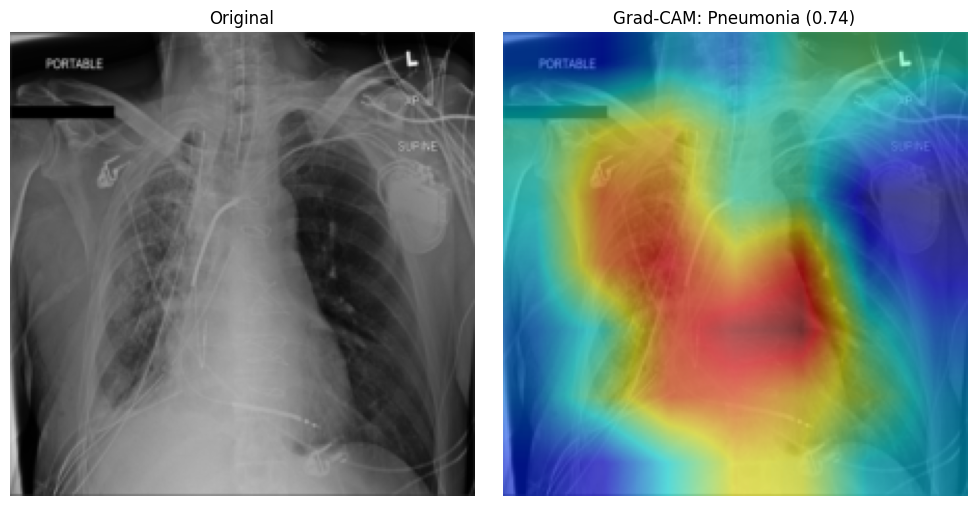

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title(f"Grad-CAM: {model.pathologies[target_category_index]} ({outputs_numpy[target_category_index]:.2f})")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("gradcam_example.png", dpi=150, bbox_inches="tight")
plt.show()